In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# 한글 폰트 설정
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

pd.set_option("display.max_columns", 50)

# 데이터 로드  
> vworld의 중개사 + 중개업자 + 피터팬 크롤링 크롤링 중개사 매칭한 데이터

In [2]:
# 데이터 로드
clean_path = r"C:/dev/study/eunjeong/SKN18-FINAL-1TEAM/data/raw/match_data_clean.csv"
df = pd.read_csv(clean_path)

print("="*50)
print("데이터 기본 정보")
print("="*50)
print(f"\n데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")
print(f"\n컬럼 목록:\n{df.columns.tolist()}")
print(f"\n데이터 타입:\n{df.dtypes}")
print(f"\n기본 통계:\n{df.describe()}")
print(f"\n결측치 정보:\n{df.isnull().sum()}")
df.head()

데이터 기본 정보

데이터 크기: 280행 x 28열

컬럼 목록:
['등록번호', '중개사명', '대표자', '주소', '거래완료', '등록매물', '빌라주택', '아파트', '오피스텔', '원투룸', '공인중개사', '법인', '중개보조원', '중개인', '감사', '대표', '이사', '일반', '대표_중개업자종별명', 'brkrNm', 'jurirno', 'ldCodeNm', 'registDe', 'rdnmadrcode', 'estbsBeginDe', 'lastUpdtDt', 'estbsEndDe', '총매물수']

데이터 타입:
등록번호             object
중개사명             object
대표자              object
주소               object
거래완료              int64
등록매물              int64
빌라주택              int64
아파트               int64
오피스텔              int64
원투룸               int64
공인중개사           float64
법인              float64
중개보조원           float64
중개인             float64
감사              float64
대표              float64
이사              float64
일반              float64
대표_중개업자종별명       object
brkrNm           object
jurirno          object
ldCodeNm         object
registDe         object
rdnmadrcode      object
estbsBeginDe     object
lastUpdtDt       object
estbsEndDe       object
총매물수              int64
dtype: object

기본 통계:
  

,등록번호,중개사명,대표자,주소,거래완료,등록매물,빌라주택,아파트,오피스텔,원투룸,공인중개사,법인,중개보조원,중개인,감사,대표,이사,일반,대표_중개업자종별명,brkrNm,jurirno,ldCodeNm,registDe,rdnmadrcode,estbsBeginDe,lastUpdtDt,estbsEndDe,총매물수
0,11170-2017-00092,용산센트럴드림부동산공인중개사사무소,안지선,"서울 용산구 서빙고로 17, 판매시설동 1층 28호(한강로3가, 용산센트럴파크해링턴...",0,0,0,1,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,공인중개사,안지선,11170-2017-00092,서울특별시 용산구,2017-06-11,11170310200400001700000,2025-06-12,2025-11-24,2026-06-11,0
1,11170-2018-00164,명성공인중개사사무소,이민경,서울특별시 용산구 효창원로 240 1층(청파동1가),76,5,1,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,공인중개사,이민경,11170-2018-00164,서울특별시 용산구,2018-09-27,1117030050220024000000,2025-09-27,2025-11-24,2026-09-26,81
2,11170-2020-00099,엘공인중개사사무소,김현임,서울특별시 용산구 후암로23길 31 1층,152,12,1,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,공인중개사,김현임,11170-2020-00099,서울특별시 용산구,2020-07-29,11170410657600003100000,2025-07-29,2025-11-24,2026-07-28,164
3,11170-2021-00062,황금부동산공인중개사사무소,이선우,서울특별시 용산구 소월로20길 42 1층(용산동2가),380,14,1,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,공인중개사,이선우,11170-2021-00062,서울특별시 용산구,2021-04-30,111704106172000042,2025-04-30,2025-11-24,2026-04-29,394
4,11170-2021-00113,토스부동산중개사무소,조미선,서울특별시 용산구 두텁바위로1길 108 1층(후암동),1,6,0,0,0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,공인중개사,조미선,11170-2021-00113,서울특별시 용산구,2021-04-20,11170410605700010800000,2025-04-20,2025-11-24,2026-04-19,7


> **컬럼**  
- > 등록번호
- > 중개사명
- > 대표자
- > 주소
- > 거래완료
- > 등록매물
- > 빌라주택
- > 아파트
- > 오피스텔
- > 원투룸
- > 공인중개사
- > 법인
- > 중개보조원
- > 중개인
- > 감사
- > 대표
- > 이사
- > 일반
- > 대표_중개업자종별명
- > brkrNm
- > jurirno
- > ldCodeNm
- > registDe
- > rdnmadrcode
- > estbsBeginDe
- > lastUpdtDt
- > estbsEndDe


# EDA_v1

## 기본 통계 & 분포 확인

수치형 컬럼: ['거래완료', '등록매물', '빌라주택', '아파트', '오피스텔', '원투룸', '공인중개사', '법인', '중개보조원', '중개인', '감사', '대표', '이사', '일반', '총매물수']


C:\Users\Playdata\AppData\Local\Temp\ipykernel_14636\2860941225.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\dev\study\eunjeong\SKN18-FINAL-1TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


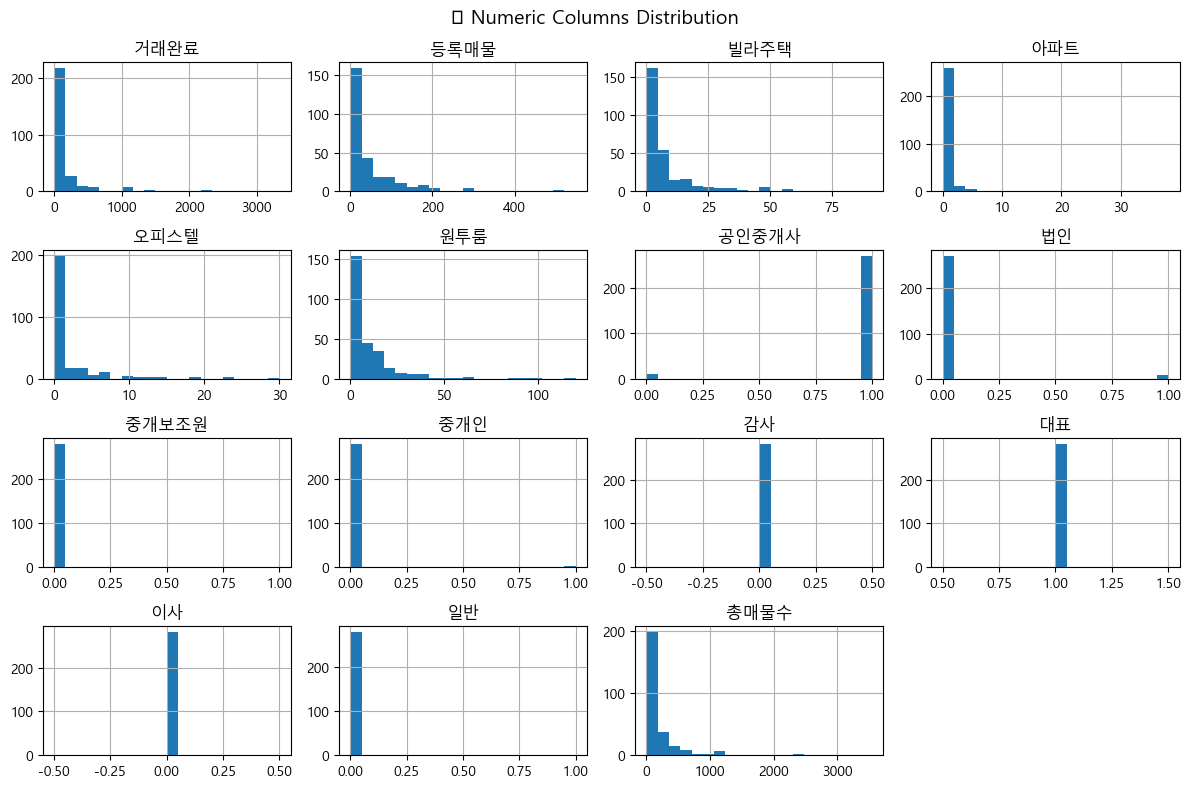


 describe(include='all') 결과


,등록번호,중개사명,대표자,주소,거래완료,등록매물,빌라주택,아파트,오피스텔,원투룸,공인중개사,법인,중개보조원,중개인,감사,대표,이사,일반,대표_중개업자종별명,brkrNm,jurirno,ldCodeNm,registDe,rdnmadrcode,estbsBeginDe,lastUpdtDt,estbsEndDe,총매물수
count,280,280,280,280,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.000000,280.0,280.0,280.0,280.000000,280,280,280,280,280,280,280,280,280,280.000000
unique,280,262,279,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,279,280,26,263,276,192,1,192,NaN
top,11170-2017-00092,한결공인중개사사무소,정진호,"서울 용산구 서빙고로 17, 판매시설동 1층 28호(한강로3가, 용산센트럴파크해링턴...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,공인중개사,정진호,11170-2017-00092,서울특별시 관악구,2025-07-01,11740200000800107700000,2024-12-30,2025-11-24,2025-12-29,NaN
freq,1,2,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,268,2,1,50,3,3,4,280,4,NaN
mean,NaN,NaN,NaN,NaN,184.617857,53.171429,8.207143,0.600000,2.457143,10.439286,0.957143,0.035714,0.003571,0.007143,0.0,1.0,0.0,0.003571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,237.789286
std,NaN,NaN,NaN,NaN,435.198616,80.071334,13.712092,2.671501,5.149202,16.125290,0.202898,0.185909,0.059761,0.084364,0.0,0.0,0.0,0.059761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,466.590826
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,5.750000,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.000000
50%,NaN,NaN,NaN,NaN,32.500000,20.500000,3.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.500000
75%,NaN,NaN,NaN,NaN,144.500000,65.250000,9.000000,0.000000,2.000000,13.250000,1.000000,0.000000,0.000000,0.000000,0.0,1.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.000000


In [3]:
# 전체 히스토그램 (수치형 컬럼만)
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
print(f"수치형 컬럼: {numeric_cols.tolist()}")

df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("📊 Numeric Columns Distribution", fontsize=14)
plt.tight_layout()
plt.show()

# 요약통계
print("\n describe(include='all') 결과")
display(df.describe(include='all'))


In [4]:
print(df.columns.tolist())
df.info()

['등록번호', '중개사명', '대표자', '주소', '거래완료', '등록매물', '빌라주택', '아파트', '오피스텔', '원투룸', '공인중개사', '법인', '중개보조원', '중개인', '감사', '대표', '이사', '일반', '대표_중개업자종별명', 'brkrNm', 'jurirno', 'ldCodeNm', 'registDe', 'rdnmadrcode', 'estbsBeginDe', 'lastUpdtDt', 'estbsEndDe', '총매물수']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   등록번호          280 non-null    object 
 1   중개사명          280 non-null    object 
 2   대표자           280 non-null    object 
 3   주소            280 non-null    object 
 4   거래완료          280 non-null    int64  
 5   등록매물          280 non-null    int64  
 6   빌라주택          280 non-null    int64  
 7   아파트           280 non-null    int64  
 8   오피스텔          280 non-null    int64  
 9   원투룸           280 non-null    int64  
 10  공인중개사         280 non-null    float64
 11  법인            280 non-null    float64
 12  중개보조원         280 non-null    f

## 거래 성사율(success_rate) 분석


📈 success_rate 기본 통계
count    280.000000
mean       0.503262
std        0.339871
min        0.000000
25%        0.177655
50%        0.501163
75%        0.841036
max        0.992958
Name: success_rate, dtype: float64


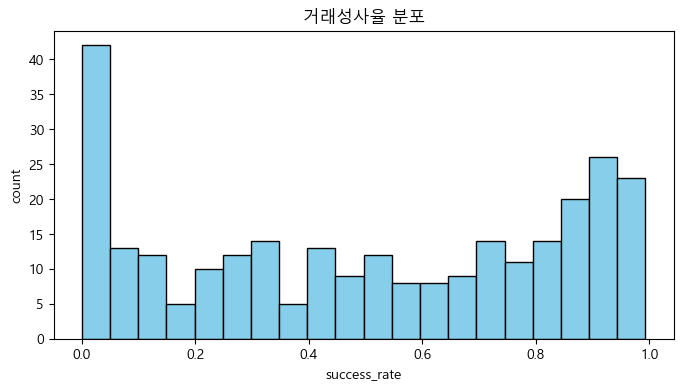


 <지역별 평균> success_rate


ldCodeNm
서울특별시 은평구     0.797122
서울특별시 중구      0.722222
서울특별시 성동구     0.707318
서울특별시 영등포구    0.649854
서울특별시 마포구     0.645281
서울특별시 강북구     0.622216
서울특별시 서대문구    0.611392
서울특별시 강서구     0.574474
서울특별시 동작구     0.563228
서울특별시 구로구     0.554008
서울특별시 용산구     0.541339
인천광역시 남동구     0.539871
서울특별시 양천구     0.539676
서울특별시 금천구     0.508282
서울특별시 광진구     0.507619
서울특별시 관악구     0.500195
서울특별시 송파구     0.488341
서울특별시 성북구     0.421808
서울특별시 강남구     0.412711
인천광역시 미추홀구    0.391063
서울특별시 동대문구    0.381563
서울특별시 서초구     0.333133
서울특별시 중랑구     0.314705
서울특별시 강동구     0.286326
서울특별시 도봉구     0.200000
서울특별시 종로구     0.142857
Name: success_rate, dtype: float64

In [8]:
# success_rate(거래 성사율) 파생 변수 생성
df["success_rate"] = df["거래완료"] / (df["총매물수"] + 1e-6)  # 0 나누기 방지

print("\n📈 success_rate 기본 통계")
print(df["success_rate"].describe())

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df["success_rate"], bins=20, color='skyblue', edgecolor='black')
plt.title("거래성사율 분포")
plt.xlabel("success_rate")
plt.ylabel("count")
plt.show()

# 지역별 평균 성사율
print("\n <지역별 평균> success_rate")
region_success = df.groupby("ldCodeNm")["success_rate"].mean().sort_values(ascending=False)
display(region_success)

In [12]:
# 양 끝단 확인
df.sort_values("success_rate").head(10)[["중개사명","거래완료","총매물수","success_rate"]]
df.sort_values("success_rate", ascending=False).head(10)[["중개사명","거래완료","총매물수","success_rate"]]

,중개사명,거래완료,총매물수,success_rate
253,베스트공인중개사사무소,282,284,0.992958
36,슈퍼맨공인중개사사무소,2404,2426,0.990932
171,위드공인중개사사무소,1081,1093,0.989021
186,오이공인중개사사무소,566,575,0.984348
74,라벨라공인중개사사무소,266,271,0.981550
17,김태희공인중개사사무소,174,178,0.977528
71,로엘공인중개사사무소,1018,1042,0.976967
28,복많이부동산공인중개사사무소,496,508,0.976378
169,119부동산공인중개사사무소,2890,2971,0.972736
133,슬기로운공인중개사사무소,1125,1161,0.968992


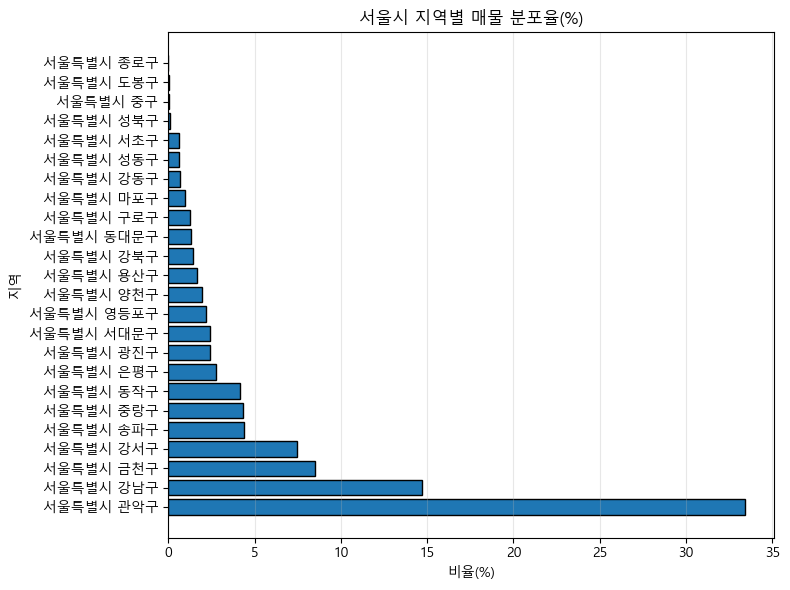

In [20]:
import matplotlib.pyplot as plt

# 1) "서울" 들어가는 지역만 필터
region_seoul = region_total[region_total["ldCodeNm"].str.contains("서울")].copy()

# 2) 비율 높은 순으로 정렬
region_seoul = region_seoul.sort_values("비율", ascending=True)  # barh 위에서 아래로 예쁘게

# 3) 가로 막대그래프
plt.figure(figsize=(8, 6))
plt.barh(region_seoul["ldCodeNm"], region_seoul["비율(%)"], edgecolor="black")

plt.title("서울시 지역별 매물 분포율(%)")
plt.xlabel("비율(%)")
plt.ylabel("지역")

# 값이 큰 애가 위로 오게 하려면 (정렬을 ascending=True로 했으니까 뒤집기)
plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

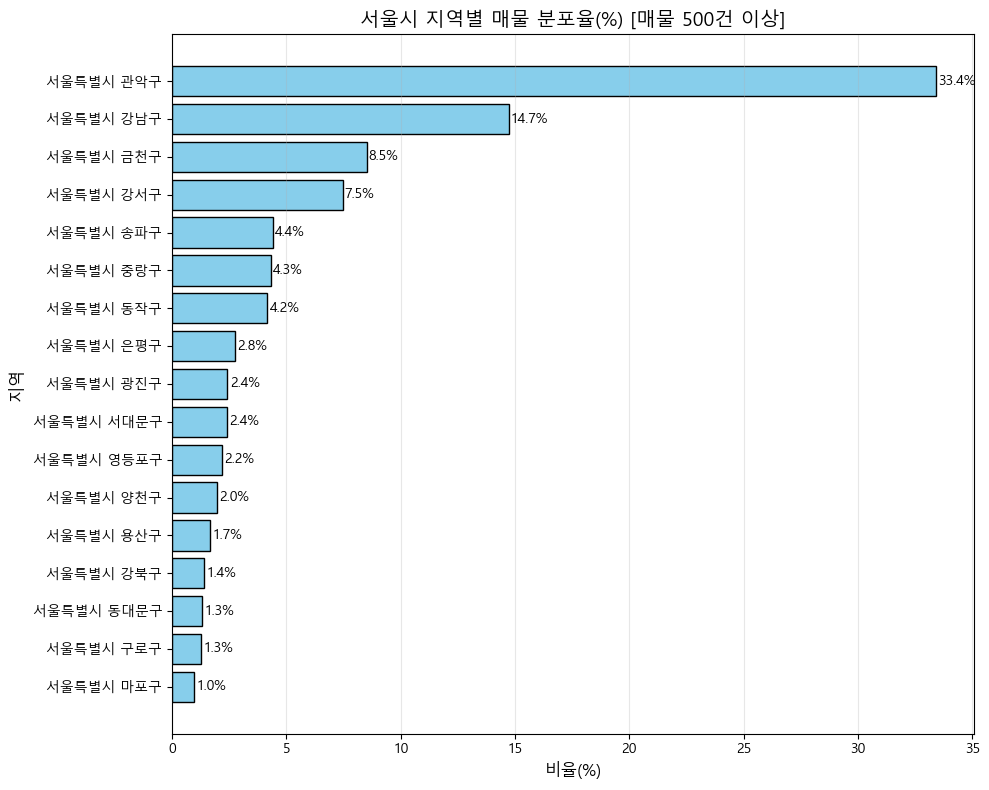

=== 서울시 지역별 매물 현황 (500건 이상) ===


,ldCodeNm,총매물수,비율(%)
4,서울특별시 관악구,22242,33.405927
0,서울특별시 강남구,9802,14.721918
7,서울특별시 금천구,5664,8.506931
3,서울특별시 강서구,4964,7.455580
16,서울특별시 송파구,2940,4.415674
23,서울특별시 중랑구,2876,4.319551
10,서울특별시 동작구,2779,4.173863
20,서울특별시 은평구,1835,2.756042
5,서울특별시 광진구,1614,2.424115
12,서울특별시 서대문구,1603,2.407594


In [22]:
# 1) 지역별 총매물수 집계 (원본 df 사용)
# ldCodeNm 별로 '총매물수'를 합산합니다.
region_total = df.groupby("ldCodeNm")['총매물수'].sum().reset_index()

# 2) 전체 대비 비율(%) 계산
total_listings = region_total['총매물수'].sum()
region_total['비율(%)'] = (region_total['총매물수'] / total_listings) * 100

# 3) 필터링: "서울" 포함 AND 총매물수 >= 500
# 조건 설정
cond_seoul = region_total["ldCodeNm"].str.contains("서울")
cond_over_500 = region_total["총매물수"] >= 500

# 필터 적용
region_seoul_filtered = region_total[cond_seoul & cond_over_500].copy()

# 4) 비율 높은 순으로 정렬 (그래프 시각화용)
region_seoul_filtered = region_seoul_filtered.sort_values("비율(%)", ascending=True)

# ----------------- 시각화 -----------------
plt.figure(figsize=(10, 8))  # 그래프 크기 조절

# 가로 막대그래프 그리기
bars = plt.barh(region_seoul_filtered["ldCodeNm"], region_seoul_filtered["비율(%)"], 
                edgecolor="black", color='skyblue')

plt.title("서울시 지역별 매물 분포율(%) [매물 500건 이상]", fontsize=14)
plt.xlabel("비율(%)", fontsize=12)
plt.ylabel("지역", fontsize=12)


# 막대 옆에 수치(건수, %) 표시 (선택사항)
for bar in bars:
    width = bar.get_width()
    # 해당 막대의 인덱스를 찾아 총매물수 가져오기 (약간 복잡할 수 있어 비율만 표시하거나 생략 가능)
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', 
             va='center', fontsize=10)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 통계 출력
print("=== 서울시 지역별 매물 현황 (500건 이상) ===")
display(region_seoul_filtered[["ldCodeNm", "총매물수", "비율(%)"]].sort_values("총매물수", ascending=False))

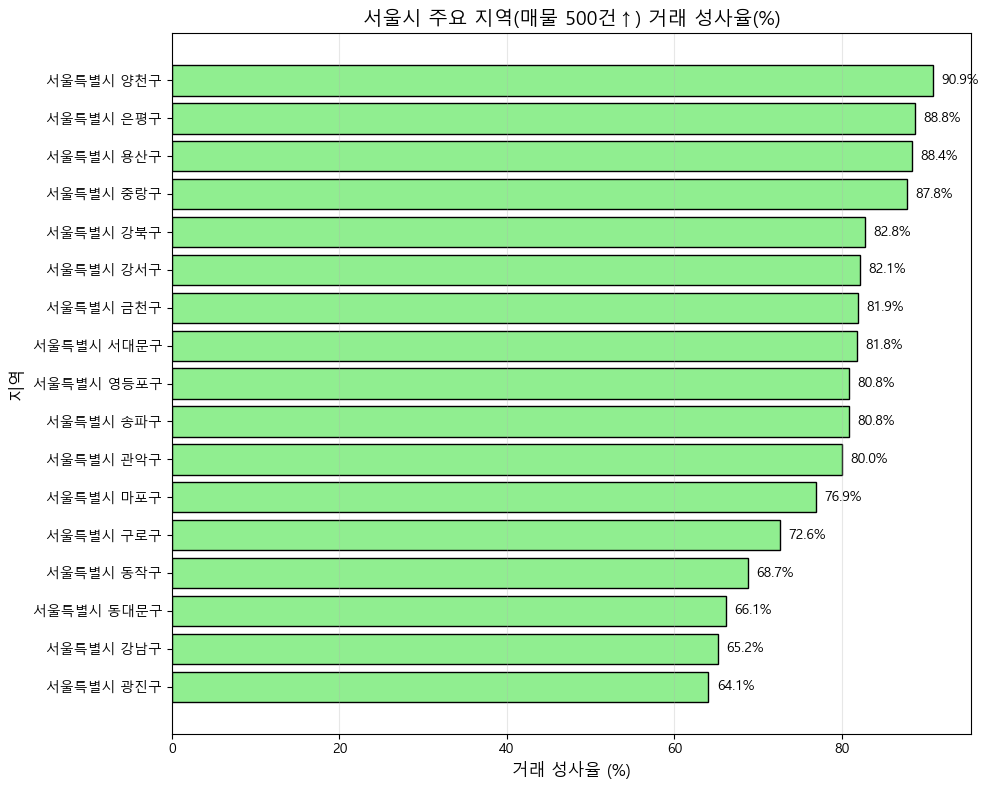

=== 서울시 주요 지역(매물 500건 이상) 거래 성사율 순위 ===


,ldCodeNm,거래완료,총매물수,거래성사율(%)
12,서울특별시 양천구,1192,1311,90.922960
15,서울특별시 은평구,1629,1835,88.773842
14,서울특별시 용산구,971,1099,88.353048
16,서울특별시 중랑구,2525,2876,87.795549
1,서울특별시 강북구,779,941,82.784272
2,서울특별시 강서구,4077,4964,82.131346
6,서울특별시 금천구,4639,5664,81.903249
10,서울특별시 서대문구,1312,1603,81.846538
13,서울특별시 영등포구,1168,1445,80.830450
11,서울특별시 송파구,2376,2940,80.816327


In [23]:
# 1) 살아남은 지역 리스트 추출 (총매물수 500건 이상인 서울 지역)
# region_seoul_filtered는 이전 단계에서 이미 만들어진 데이터프레임입니다.
target_regions = region_seoul_filtered["ldCodeNm"].unique()

# 2) 원본 df에서 해당 지역들만 필터링
df_filtered = df[df["ldCodeNm"].isin(target_regions)].copy()

# 3) 지역별 거래완료 & 총매물수 합계 집계
# 단순 평균(mean)이 아니라, 지역 전체의 (총 거래완료 수 / 총 매물 수)로 계산해야 정확합니다.
region_stats = df_filtered.groupby("ldCodeNm")[["거래완료", "총매물수"]].sum().reset_index()

# 4) 거래 성사율 계산
# 0으로 나누는 것을 방지하기 위해 분모에 작은 값(1e-9)을 더해주거나 처리할 수 있으나, 500건 이상이므로 그대로 진행합니다.
region_stats["거래성사율(%)"] = (region_stats["거래완료"] / region_stats["총매물수"]) * 100

# 5) 성사율 높은 순으로 정렬
region_stats = region_stats.sort_values("거래성사율(%)", ascending=True)

# ----------------- 시각화 -----------------
plt.figure(figsize=(10, 8))

# 가로 막대 그래프
# 색상은 가시성을 위해 다른 색(예: 'lightgreen') 사용
bars = plt.barh(region_stats["ldCodeNm"], region_stats["거래성사율(%)"], 
                edgecolor="black", color='lightgreen')

plt.title("서울시 주요 지역(매물 500건↑) 거래 성사율(%)", fontsize=14)
plt.xlabel("거래 성사율 (%)", fontsize=12)
plt.ylabel("지역", fontsize=12)

# 막대 옆에 수치 표시
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}%', 
             va='center', fontsize=10)

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 결과 텍스트 출력
print("=== 서울시 주요 지역(매물 500건 이상) 거래 성사율 순위 ===")
display(region_stats[["ldCodeNm", "거래완료", "총매물수", "거래성사율(%)"]].sort_values("거래성사율(%)", ascending=False))

      ldCodeNm   거래완료   총매물수  region_success_rate
13   서울특별시 서초구     55    401             0.137157
21   서울특별시 종로구      1      7             0.142857
8    서울특별시 도봉구      3     15             0.200000
5    서울특별시 광진구   1034   1614             0.640644
0    서울특별시 강남구   6390   9802             0.651908
9   서울특별시 동대문구    576    871             0.661309
10   서울특별시 동작구   1910   2779             0.687298
1    서울특별시 강동구    310    439             0.706150
22    서울특별시 중구     26     36             0.722222
15   서울특별시 성북구     42     58             0.724138
6    서울특별시 구로구    622    857             0.725788
11   서울특별시 마포구    502    653             0.768760
4    서울특별시 관악구  17796  22242             0.800108
16   서울특별시 송파구   2376   2940             0.808163
18  서울특별시 영등포구   1168   1445             0.808304
12  서울특별시 서대문구   1312   1603             0.818465
7    서울특별시 금천구   4639   5664             0.819032
3    서울특별시 강서구   4077   4964             0.821313
2    서울특별시 강북구    779    941             0.827843


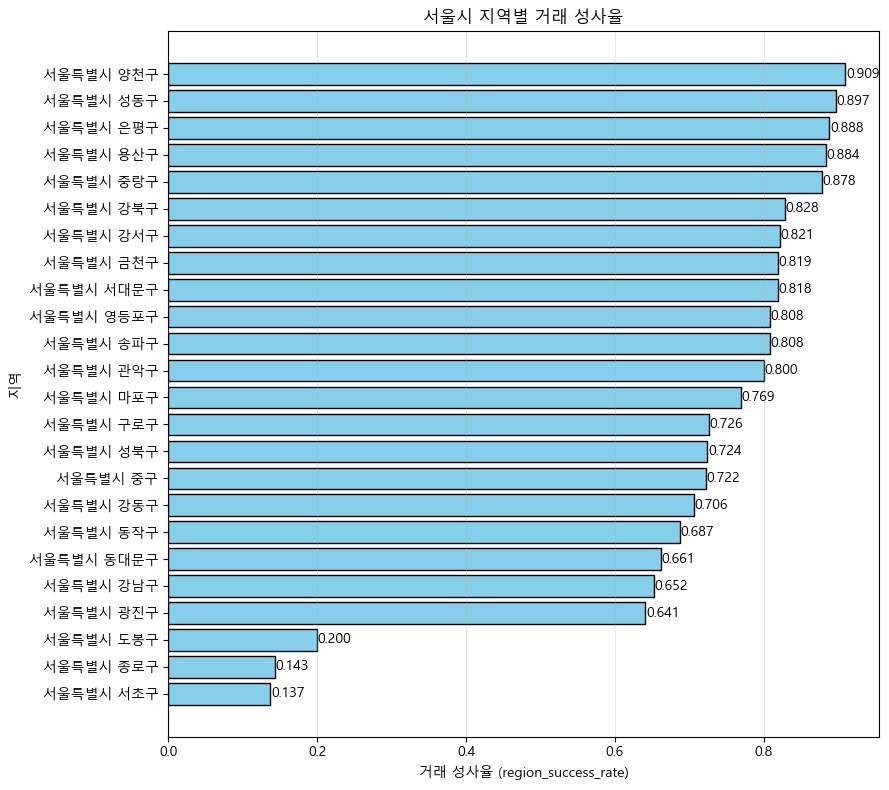

In [21]:
# 1) 숫자형 정리
df["거래완료"] = pd.to_numeric(df["거래완료"], errors="coerce").fillna(0)
df["총매물수"] = pd.to_numeric(df["총매물수"], errors="coerce").fillna(0)

# 2) 지역별 집계 (거래완료 합, 총매물수 합)
region_agg = (
    df.groupby("ldCodeNm")[["거래완료", "총매물수"]]
      .sum()
      .reset_index()
)

# 3) 지역별 성사율 계산
region_agg["region_success_rate"] = (
    region_agg["거래완료"] / (region_agg["총매물수"] + 1e-6)
)

# 4) 서울만 필터링
region_seoul = region_agg[region_agg["ldCodeNm"].str.contains("서울")].copy()

# 5) 그래프 보기 좋게 오름차순 정렬
region_seoul = region_seoul.sort_values("region_success_rate", ascending=True)

print(region_seoul)

# 6) 가로막대그래프(barh)
plt.figure(figsize=(9, 8))
plt.barh(
    region_seoul["ldCodeNm"],
    region_seoul["region_success_rate"],
    color="skyblue",
    edgecolor="black"
)

plt.title("서울시 지역별 거래 성사율")
plt.xlabel("거래 성사율 (region_success_rate)")
plt.ylabel("지역")

# 성사율 값 표시 (선택)
for index, value in enumerate(region_seoul["region_success_rate"]):
    plt.text(value + 0.001, index, f"{value:.3f}", va='center')

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 보증보험 분석

In [6]:
# 보증보험 유효 여부 확인

# 날짜 변환
df["estbsBeginDe"] = pd.to_datetime(df["estbsBeginDe"], errors='coerce')
df["estbsEndDe"] = pd.to_datetime(df["estbsEndDe"], errors='coerce')

# 거래성사율 생성 (없으면)
if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)

# 보증보험 유효 여부
today = pd.Timestamp.today()
df["보증보험유효"] = (df["estbsEndDe"] >= today).astype(int)

print(f"유효: {df['보증보험유효'].sum()}개")
print(f"만료: {(df['보증보험유효'] == 0).sum()}개")

# 만료된 중개사 전체 정보
expired = df[df['보증보험유효'] == 0]

if len(expired) > 0:
    print(f"\n보증보험 만료 중개사 ({len(expired)}개):\n")
    
    for idx, row in expired.iterrows():
        print(f"{'='*60}")
        print(f"중개사: {row['brkrNm']} ({row['bsnmCmpnm']})")
        print(f"지역: {row['ldCodeNm']}")
        print(f"보험만료: {row['estbsEndDe'].strftime('%Y-%m-%d')}")
        print(f"거래완료: {row['거래완료']}건 / 총매물: {row['총매물수']}건")
        print(f"거래성사율: {row['거래성사율']:.1%}")
        print()


유효: 272개
만료: 8개

보증보험 만료 중개사 (8개):



KeyError: 'bsnmCmpnm'

## 개업일(registDe) 분석

In [ ]:
# 날짜로 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')

# 활동 연차 계산
df["years_active"] = pd.Timestamp.today().year - df["registDe"].dt.year

print("\n📈 years_active 기본 통계")
print(df["years_active"].describe())

# 히스토그램
plt.figure(figsize=(8, 4))
plt.hist(df["years_active"], bins=20, color='orange', edgecolor='black')
plt.title("중개사 개업 연차 분포")
plt.xlabel("years_active")
plt.ylabel("count")
plt.show()


In [ ]:
# 연차 vs 거래성사율 상관관계 분석

# 날짜 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')

# 활동 연차 계산
df["years_active"] = pd.Timestamp.today().year - df["registDe"].dt.year

# 상관계수 계산
correlation = df[["years_active", "거래성사율"]].corr().iloc[0, 1]
print(f"상관계수: {correlation:.3f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot with regression line
axes[0].scatter(df["years_active"], df["거래성사율"], alpha=0.5, s=30)
z = np.polyfit(df["years_active"], df["거래성사율"], 1)
p = np.poly1d(z)
axes[0].plot(df["years_active"], p(df["years_active"]), "r--", linewidth=2, label=f'회귀선 (r={correlation:.3f})')
axes[0].set_xlabel('활동 연차', fontsize=12)
axes[0].set_ylabel('거래성사율', fontsize=12)
axes[0].set_title('연차 vs 거래성사율', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Boxplot (연차 구간별)
df['연차구간'] = pd.cut(df['years_active'], bins=[0, 5, 10, 15, 20, 100], 
                        labels=['0-5년', '6-10년', '11-15년', '16-20년', '20년+'])
df.boxplot(column='거래성사율', by='연차구간', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('연차 구간', fontsize=12)
axes[1].set_ylabel('거래성사율', fontsize=12)
axes[1].set_title('연차 구간별 거래성사율 분포', fontsize=13, fontweight='bold')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()


## 컬럼 간 상관관계 분석

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["거래완료","등록매물","총매물수","success_rate","years_active"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("상관관계 분석")
plt.show()


## 지역별 분석

In [ ]:
# 1. 지역별 기본 통계

if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)

region_stats = df.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래완료': ['mean', 'median', 'sum'],
    '총매물수': ['mean', 'median'],
    '거래성사율': ['mean', 'median']
}).round(2)

region_stats.columns = ['중개사수', '평균거래', '중앙거래', '총거래', '평균매물', '중앙매물', '평균성사율', '중앙성사율']
region_stats = region_stats.sort_values('평균성사율', ascending=False)

print("="*70)
print("지역별 통계")
print("="*70)
print(region_stats)

In [ ]:
# 2. 시각화 - 지역별 중개사 수
plt.figure(figsize=(12, 6))
region_counts = df['ldCodeNm'].value_counts()
region_counts.plot(kind='bar', color='steelblue')
plt.title('지역별 중개사 수', fontsize= 14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('중개사 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# 3. 시각화 - 지역별 평균 거래성사율
plt.figure(figsize=(12, 6))
region_success = df.groupby('ldCodeNm')['거래성사율'].mean().sort_values(ascending=False)
region_success.plot(kind='bar', color='green', alpha=0.7)
plt.title('지역별 평균 거래성사율', fontsize=14, fontweight='bold')
plt.xlabel('지역')
plt.ylabel('평균 거래성사율')
plt.axhline(df['거래성사율'].mean(), color='red', linestyle='--', label=f'전체 평균: {df["거래성사율"].mean():.1%}')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 4. 지역별 규모 vs 성과
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 중개사 수 vs 평균 성과
region_summary = df.groupby('ldCodeNm').agg({
    '등록번호': 'count',
    '거래성사율': 'mean',
    '총매물수': 'mean'
})
region_summary.columns = ['중개사수', '평균성사율', '평균매물수']

axes[0].scatter(region_summary['중개사수'], region_summary['평균성사율'], 
                s=region_summary['평균매물수']/10, alpha=0.6, c=region_summary['평균성사율'], 
                cmap='RdYlGn')
axes[0].set_xlabel('지역 내 중개사 수')
axes[0].set_ylabel('평균 거래성사율')
axes[0].set_title('지역별 중개사 수 vs 평균 성과')

# 평균 매물수 vs 평균 성과
axes[1].scatter(region_summary['평균매물수'], region_summary['평균성사율'],
                s=region_summary['중개사수']*10, alpha=0.6, c=region_summary['평균성사율'],
                cmap='RdYlGn')
axes[1].set_xlabel('평균 총매물수')
axes[1].set_ylabel('평균 거래성사율')
axes[1].set_title('지역별 평균 규모 vs 평균 성과')
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# 상호명이 같고 등록번호, 거래완료, 총매물수가 같은건 하나만 남기고 삭제하기

In [ ]:
df["bsnmCmpnm"].nunique()

In [ ]:
office_counts = df["bsnmCmpnm"].value_counts()

print("중복된 상호명 개수:", (office_counts > 1).sum())
print("\n상위 중복 상호명:")
print(office_counts[office_counts > 1].head(10))

# 중복된 상호명의 실제 데이터 확인
duplicated_offices = office_counts[office_counts > 1].index[:3]
for office in duplicated_offices:
    print(f"\n{'='*60}")
    print(f"상호명: {office}")
    print(df[df['bsnmCmpnm'] == office][['brkrNm', 'ldCodeNm', '등록번호', '거래완료', '총매물수']])


---

# 파생 피처 생성

In [ ]:
# 0. 날짜 변환
df["registDe"] = pd.to_datetime(df["registDe"], errors='coerce')
df["estbsBeginDe"] = pd.to_datetime(df["estbsBeginDe"], errors='coerce')
df["estbsEndDe"] = pd.to_datetime(df["estbsEndDe"], errors='coerce')

In [ ]:
# 1. 거래 효율성 피처
if '거래성사율' not in df.columns:
    df['거래성사율'] = df['거래완료'] / (df['총매물수'] + 1)
df['재고율'] = df['등록매물'] / (df['총매물수'] + 1)
df['거래재고비'] = df['거래완료'] / (df['등록매물'] + 1)

# 2. 규모 관련 피처
df['총매물수_로그'] = np.log1p(df['총매물수'])
df['안정구간여부'] = (df['총매물수'] >= 100).astype(int)
df['규모등급'] = pd.cut(df['총매물수'], 
                        bins=[0, 50, 100, 500, 1000, float('inf')],
                        labels=['초소형', '소형', '중형', '대형', '초대형'])


In [ ]:
# 3. 시간 관련 피처
df['영업일수'] = (df['estbsEndDe'] - df['estbsBeginDe']).dt.days
df['등록일수'] = (pd.Timestamp.now() - df['registDe']).dt.days
df['영업년수'] = df['영업일수'] / 365
df['등록년수'] = df['등록일수'] / 365

In [ ]:
# 4. 활동성 피처

df['일평균거래'] = df['거래완료'] / (df['영업일수'] + 1)
df['일평균매물'] = df['총매물수'] / (df['영업일수'] + 1)
df['연평균거래'] = df['거래완료'] / (df['영업년수'] + 1)

In [ ]:
# 5. 지역 기반 피처
df['지역평균성사율'] = df.groupby('ldCodeNm')['거래성사율'].transform('mean')
df['지역대비성과'] = df['거래성사율'] - df['지역평균성사율']
df['지역평균매물수'] = df.groupby('ldCodeNm')['총매물수'].transform('mean')
df['지역내순위'] = df.groupby('ldCodeNm')['거래성사율'].rank(ascending=False, method='dense')

In [ ]:
# 6. 연차 관련 피처
if 'years_active' not in df.columns:
    df['years_active'] = pd.Timestamp.today().year - df['registDe'].dt.year
    
df['경험등급'] = pd.cut(df['years_active'],
                        bins=[0, 5, 10, 15, 20, 100],
                        labels=['신규', '초급', '중급', '고급', '전문가'])

In [ ]:
# 7. 성과 플래그
df['고성과플래그'] = ((df['거래성사율'] >= 0.95) & (df['총매물수'] >= 100)).astype(int)
df['저성과플래그'] = ((df['거래성사율'] < 0.5) & (df['총매물수'] >= 10)).astype(int)

In [ ]:
# 8. 상호작용 피처
df['규모X지역평균'] = df['총매물수_로그'] * df['지역평균성사율']
df['연차X규모'] = df['years_active'] * df['총매물수_로그']

In [ ]:
print(f"\n최종 데이터 shape: {df.shape}")
print(f"원본 컬럼: 13개")
print(f"생성된 피처: {df.shape[1] - 13}개")

In [ ]:
# ============================================================================
# 백분위 기반 등급 분류
# ============================================================================

# 백분위 기반 등급 (각 등급이 비슷한 비율로 분포)
df['trust_grade'] = pd.qcut(df['trust_score'], 
                             q=5, 
                             labels=['D', 'C', 'B', 'A', 'S'],
                             duplicates='drop')

print("="*70)
print("백분위 기반 등급 분포")
print("="*70)
grade_dist = df['trust_grade'].value_counts().sort_index()
for grade, count in grade_dist.items():
    pct = count / len(df) * 100
    print(f"  {grade}등급: {count:3d}개 ({pct:5.1f}%)")

# 등급별 점수 범위
print("\n등급별 점수 범위:")
grade_ranges = df.groupby('trust_grade')['trust_score'].agg(['min', 'max', 'mean'])
grade_ranges.columns = ['최소', '최대', '평균']
print(grade_ranges.round(1))

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 등급별 분포 (파이 차트)
grade_counts = df['trust_grade'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#ffff00', '#2ca02c', '#1f77b4']  # D=빨강, C=주황, B=노랑, A=초록, S=파랑
axes[0].pie(grade_counts, labels=grade_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('신뢰도 등급 분포', fontsize=13, fontweight='bold')

# 등급별 점수 박스플롯
df.boxplot(column='trust_score', by='trust_grade', ax=axes[1], patch_artist=True)
axes[1].set_xlabel('등급', fontsize=12)
axes[1].set_ylabel('신뢰도 점수', fontsize=12)
axes[1].set_title('등급별 점수 분포', fontsize=13, fontweight='bold')
axes[1].get_figure().suptitle('')

plt.tight_layout()
plt.show()

# 등급별 특성 비교
print("\n" + "="*70)
print("등급별 평균 특성")
print("="*70)
grade_features = df.groupby('trust_grade').agg({
    'trust_score': 'mean',
    '거래성사율': 'mean',
    '총매물수': 'mean',
    '재고율': 'mean',
    '일평균거래': 'mean',
    '영업년수': 'mean'
}).round(2)
grade_features.columns = ['평균점수', '거래성사율', '총매물수', '재고율', '일평균거래', '영업년수']
print(grade_features)

# 각 등급별 대표 중개사
print("\n" + "="*70)
print("등급별 대표 중개사 (각 등급 상위 3개)")
print("="*70)
for grade in ['S', 'A', 'B', 'C', 'D']:
    grade_df = df[df['trust_grade'] == grade].nlargest(3, 'trust_score')
    if len(grade_df) > 0:
        print(f"\n{grade}등급:")
        for idx, row in grade_df.iterrows():
            print(f"  - {row['brkrNm']} ({row['ldCodeNm']}): {row['trust_score']:.1f}점")


# 파생 피쳐 끝

## 학습에 쓸 데이터 준비

In [ ]:
# 타겟 변수
# 회귀: trust_score (0~100점 예측)
# 분류: trust_grade (S/A/B/C/D 예측)

# 사용할 피처 선택
feature_cols = [
    # 수치형 피처
    '총매물수_로그',
    '일평균거래',
    '연평균거래',
    '지역평균성사율',
    '지역대비성과',
    '지역내순위',
    '영업년수',
    '등록년수',
    '규모X지역평균',
    '연차X규모',
    '안정구간여부',
    
    # 카테고리 피처
    'ldCodeNm',
    '규모등급',
    '경험등급'
]

# 카테고리 vs 수치형 분리
categorical_features = ['ldCodeNm', '규모등급', '경험등급']
numerical_features = [col for col in feature_cols if col not in categorical_features]

print(f"수치형 피처: {len(numerical_features)}개")
print(numerical_features)
print(f"\n카테고리 피처: {len(categorical_features)}개")
print(categorical_features)


## Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

# 회귀 문제로 진행 (점수 예측)
X = df[feature_cols]
y = df['trust_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train 점수 범위: {y_train.min():.1f} ~ {y_train.max():.1f}")
print(f"Test 점수 범위: {y_test.min():.1f} ~ {y_test.max():.1f}")


## 전처리 파이프라인

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

print("✓ 전처리 파이프라인 생성 완료")


## 모델 학습

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge': Ridge(alpha=1.0)
}

results = {}

for name, model in models.items():
    # 파이프라인 생성
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # 학습
    pipeline.fit(X_train, y_train)
    
    # 예측
    y_pred = pipeline.predict(X_test)
    
    # 평가
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mae,
        'R2': r2,
        'model': pipeline
    }
    
    print(f"\n{name}:")
    print(f"  RMSE: {np.sqrt(mse):.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R²: {r2:.3f}")

# 최고 성능 모델
best_model_name = max(results, key=lambda x: results[x]['R2'])
print(f"\n✓ 최고 성능 모델: {best_model_name} (R² = {results[best_model_name]['R2']:.3f})")


## 예측 결과 시각화

In [ ]:
best_model = results[best_model_name]['model']
y_pred = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 실제 vs 예측
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('실제 점수', fontsize=12)
axes[0].set_ylabel('예측 점수', fontsize=12)
axes[0].set_title(f'{best_model_name}: 실제 vs 예측', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# 오차 분포
errors = y_test - y_pred
axes[1].hist(errors, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('오차 (실제 - 예측)', fontsize=12)
axes[1].set_ylabel('빈도', fontsize=12)
axes[1].set_title('예측 오차 분포', fontsize=13, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Test 데이터로 모델 성능 확인

In [ ]:
# 1. Test 데이터 예측
y_pred_test = best_model.predict(X_test)

# 2. 성능 지표 계산
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("="*70)
print(f"{best_model_name} - Test 데이터 성능")
print("="*70)
print(f"RMSE (평균 오차):     {rmse:.2f}점")
print(f"MAE (절대 오차):      {mae:.2f}점")
print(f"R² (결정계수):        {r2:.3f}")
print(f"\n해석:")
print(f"  - 평균적으로 실제 점수와 ±{mae:.1f}점 차이")
print(f"  - 전체 분산의 {r2*100:.1f}%를 설명")

# 3. Test 데이터 결과 상세 확인
test_results = pd.DataFrame({
    '실제점수': y_test.values,
    '예측점수': y_pred_test,
    '오차': y_test.values - y_pred_test,
    '절대오차': np.abs(y_test.values - y_pred_test)
})

# 원본 데이터 정보 추가
test_results['중개사명'] = df.loc[y_test.index, 'brkrNm'].values
test_results['지역'] = df.loc[y_test.index, 'ldCodeNm'].values
test_results['실제등급'] = df.loc[y_test.index, 'trust_grade'].values

# 예측 점수로 등급 부여
test_results['예측등급'] = pd.cut(test_results['예측점수'],
                                bins=df.groupby('trust_grade')['trust_score'].min().sort_values().values.tolist() + [100],
                                labels=['D', 'C', 'B', 'A', 'S'],
                                include_lowest=True)

print("\n" + "="*70)
print("Test 데이터 샘플 (랜덤 10개)")
print("="*70)
print(test_results.sample(10).to_string(index=False))

# 4. 오차가 큰 케이스 분석
print("\n" + "="*70)
print("예측 오차가 큰 케이스 Top 5 (과대평가)")
print("="*70)
worst_overpredict = test_results.nlargest(5, '오차')[['중개사명', '지역', '실제점수', '예측점수', '오차', '실제등급', '예측등급']]
print(worst_overpredict.to_string(index=False))

print("\n" + "="*70)
print("예측 오차가 큰 케이스 Top 5 (과소평가)")
print("="*70)
worst_underpredict = test_results.nsmallest(5, '오차')[['중개사명', '지역', '실제점수', '예측점수', '오차', '실제등급', '예측등급']]
print(worst_underpredict.to_string(index=False))

# 5. 등급 일치율
grade_match = (test_results['실제등급'] == test_results['예측등급']).sum()
grade_accuracy = grade_match / len(test_results) * 100

print("\n" + "="*70)
print("등급 예측 정확도")
print("="*70)
print(f"등급 일치: {grade_match}/{len(test_results)} ({grade_accuracy:.1f}%)")

# 등급별 혼동 행렬
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_results['실제등급'], test_results['예측등급'], 
                      labels=['D', 'C', 'B', 'A', 'S'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['D', 'C', 'B', 'A', 'S'],
            yticklabels=['D', 'C', 'B', 'A', 'S'])
plt.xlabel('예측 등급', fontsize=12)
plt.ylabel('실제 등급', fontsize=12)
plt.title('등급 예측 혼동 행렬', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. 오차 통계
print("\n" + "="*70)
print("오차 통계")
print("="*70)
print(test_results['오차'].describe())


## SHAP으로 피처 중요도 분석

In [ ]:
# SHAP 설치 (필요시)
!pip install shap

import shap

# 1. SHAP Explainer 생성
# 전처리된 데이터 준비
X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)

# 피처 이름 가져오기
feature_names = (numerical_features + 
                 list(best_model.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

print(f"전처리 후 피처 수: {len(feature_names)}개")

# Explainer 생성 (Gradient Boosting용)
explainer = shap.TreeExplainer(best_model.named_steps['regressor'])
shap_values = explainer.shap_values(X_test_transformed)

print("✓ SHAP 값 계산 완료")


In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_transformed, 
                  feature_names=feature_names,
                  plot_type="bar",
                  show=False)
plt.title('SHAP 피처 중요도 (전체)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
